In [ ]:
import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
import LammpsWriter as LammpsWriter
import matplotlib.pyplot as plt
import numpy as np
import os
%load_ext autoreload
%autoreload 2

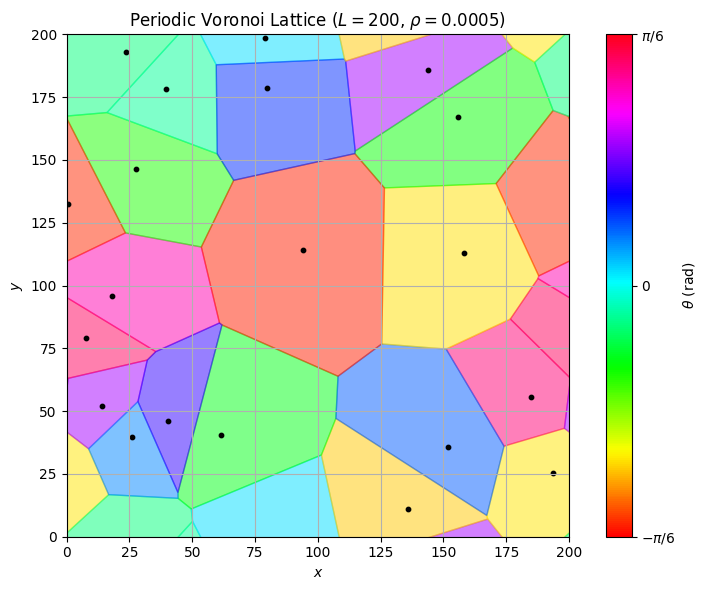

Monte Carlo Sweeps: 100%|██████████| 100000/100000 [00:00<00:00, 141643.14it/s]


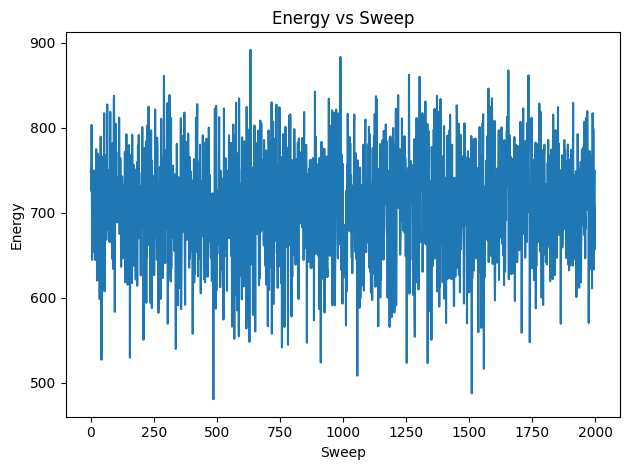

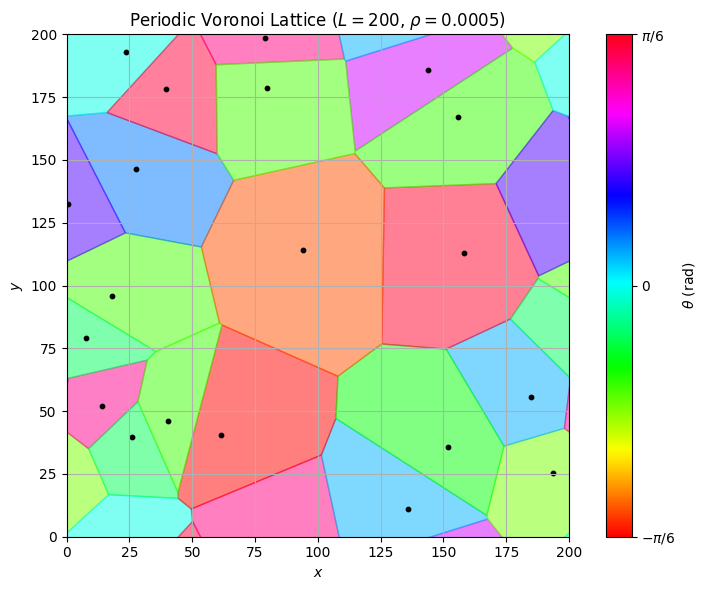

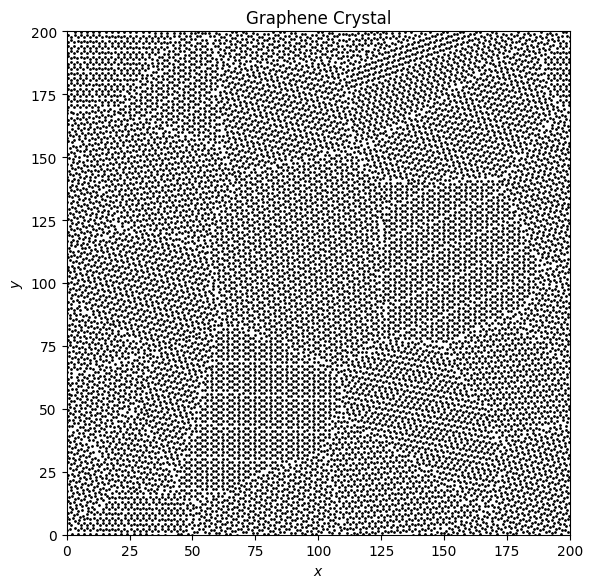

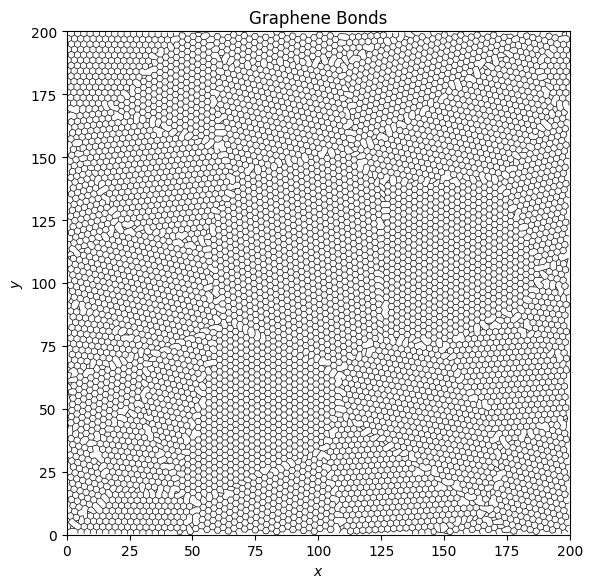

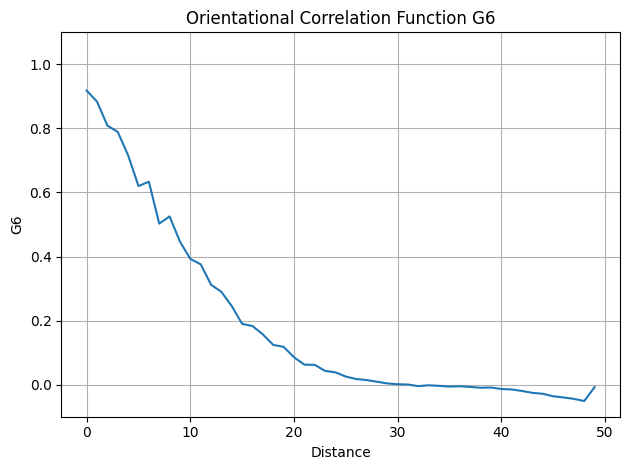

In [ ]:
L = 200
rho = 0.0005
lat = Voronoi.PeriodicVoronoi(L, rho)
lat.plot()
plt.show()

T = 100
beta = 1 / T
epsilon = 0.0
gamma = 1.0
theta, energy = MonteCarlo.monte_carlo(lat.theta.copy(), lat.adj_i, lat.adj_j, lat.adj_length, beta, epsilon, rho, gamma, n_sweeps=100000)

plt.plot(energy)
plt.xlabel('Sweep')
plt.ylabel('Energy')
plt.title('Energy vs Sweep')
plt.tight_layout()
plt.show()

lat.theta = theta
lat.plot()
plt.show()

graphene = Graphene.GrapheneCrystal(lat, a=1.42)
graphene.plot_atoms()
# plt.savefig(f"results/Graphene_atoms_T{T}.pdf")
plt.show()

graphene.plot_bonds()
# plt.savefig(f"results/Graphene_bonds_T{T}.pdf")
plt.show()

graphene.compute_observables()
plt.plot(graphene.G6)
plt.ylim(-0.1, 1.1)
plt.xlabel('Distance')
plt.ylabel('G6')
plt.title('Orientational Correlation Function G6')
plt.grid()
plt.tight_layout()
# plt.savefig(f"results/G6_T{T}.pdf")
plt.show()



In [ ]:
name = 